In [2]:
import pandas as pd
import numpy as np

adj_close   = pd.read_csv("./input/수정주가_현금배당반영_MKT.csv", index_col=0, parse_dates=True)
close       = pd.read_csv("./input/종가_MKT.csv", index_col=0, parse_dates=True)
share       = pd.read_csv("./input/상장주식수_보통주_MKT.csv", index_col=0, parse_dates=True)

---
#### **시장 수익률 계산**

In [3]:
ME              = close * share
monthly_returns = adj_close.pct_change(fill_method=None)

In [4]:
month_ends                   = monthly_returns['A005930'].dropna().index

portfolio_ret                = pd.Series(dtype=float).rename("MKT")
portfolio_ret[month_ends[0]] = 0.0

asset_num                    = pd.Series(dtype=float)

In [5]:
for i in range(0, len(month_ends) - 1):

    # 1. 리밸런싱 기간 설정
    start_date = month_ends[i]
    end_date   = month_ends[i + 1]

    # 2. 수익률
    returns = monthly_returns.loc[end_date].dropna()
    basket  = returns.index

    # 3. 시가총액 가중치 계산
    cap     = ME.loc[start_date, basket]
    weights = cap / cap.sum()

    # 4. 포트폴리오 수익률 계산
    portfolio_ret.loc[end_date] = (returns * weights).sum()

    # 5. 포트폴리오에 포함된 자산 수 계산
    asset_num.loc[start_date] = len(basket)

<Axes: >

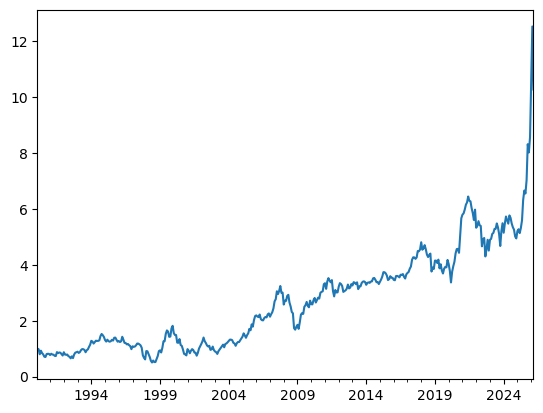

In [6]:
(portfolio_ret+1).cumprod().plot()

<Axes: >

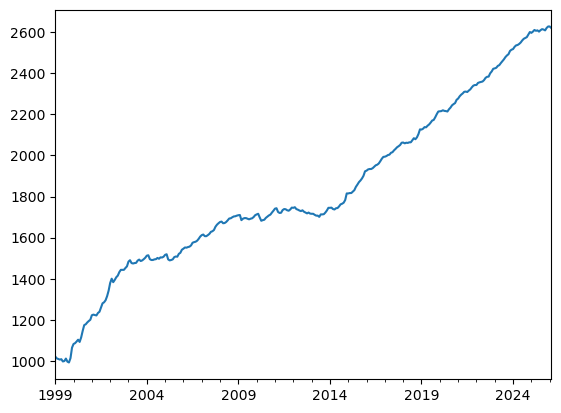

In [7]:
asset_num.loc["1999":].plot()

In [8]:
portfolio_ret.to_csv("./output/mkt_portfolio_ret.csv")